# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
from skimage import data

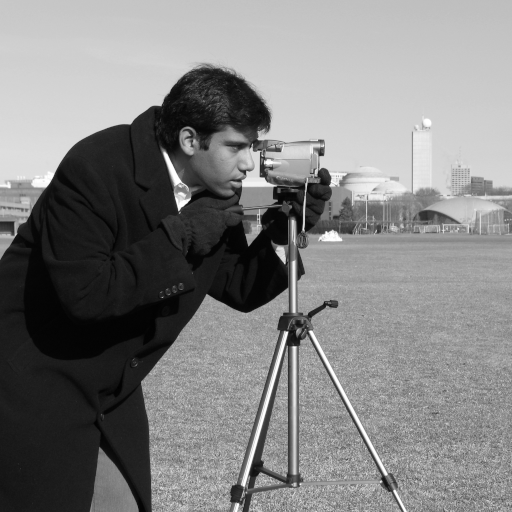

In [2]:
# ── Load image ────────────────────────────────────
camera_array = data.camera()
img = Image.fromarray(camera_array)
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size
print(f"Original size: {width} x {height}")

# scaling factors
cx, cy = 2, 2

Original size: 512 x 512


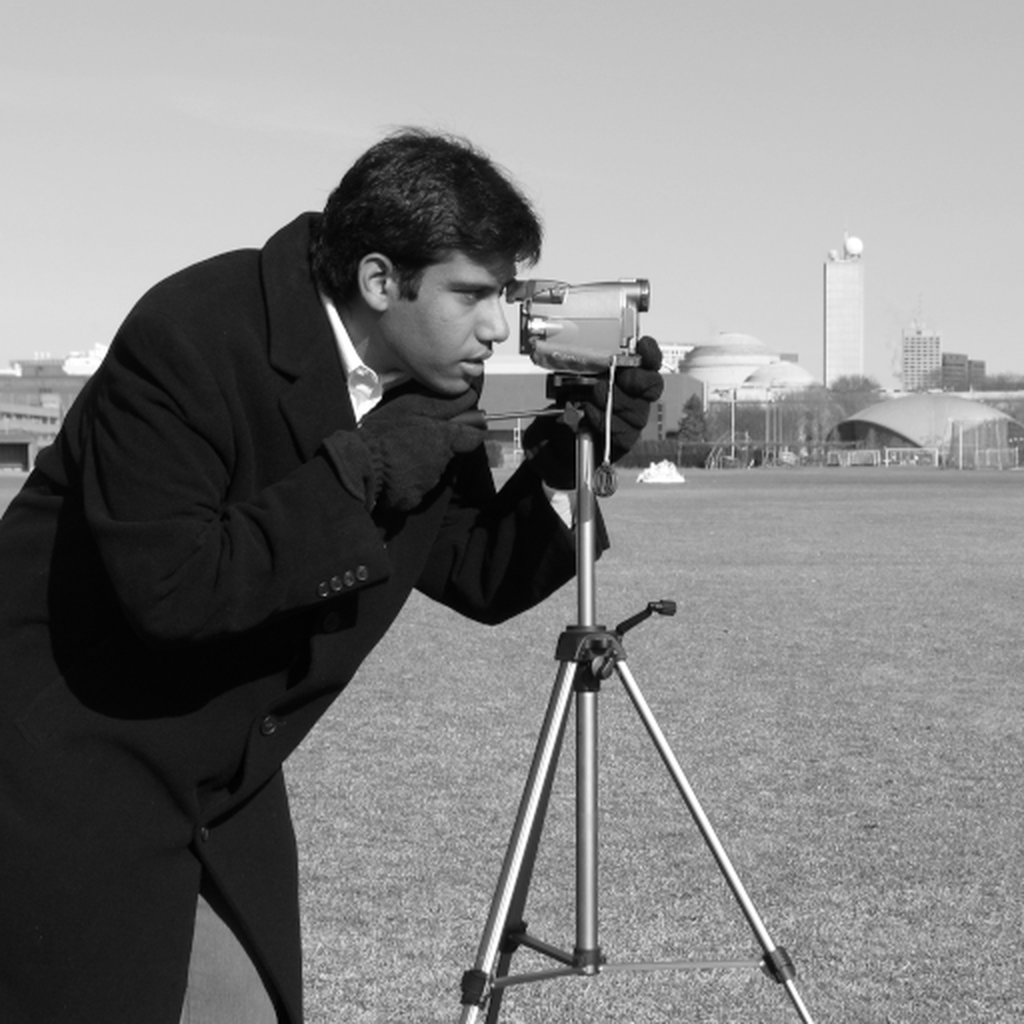

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────
new_size = (width * cx, height * cy)
# Resize the image using PIL's built-in method
scaled_img = img.resize(new_size, resample=Image.LANCZOS)
scaled_img

In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")
print(f"Original size: {img.size}")
print(f"Scaled size:   {scaled_img.size}")

Original size: (512, 512)
Scaled size:   (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
cx_nu, cy_nu = 2, 1
new_size_nu = (int(width * cx_nu), int(height * cy_nu))

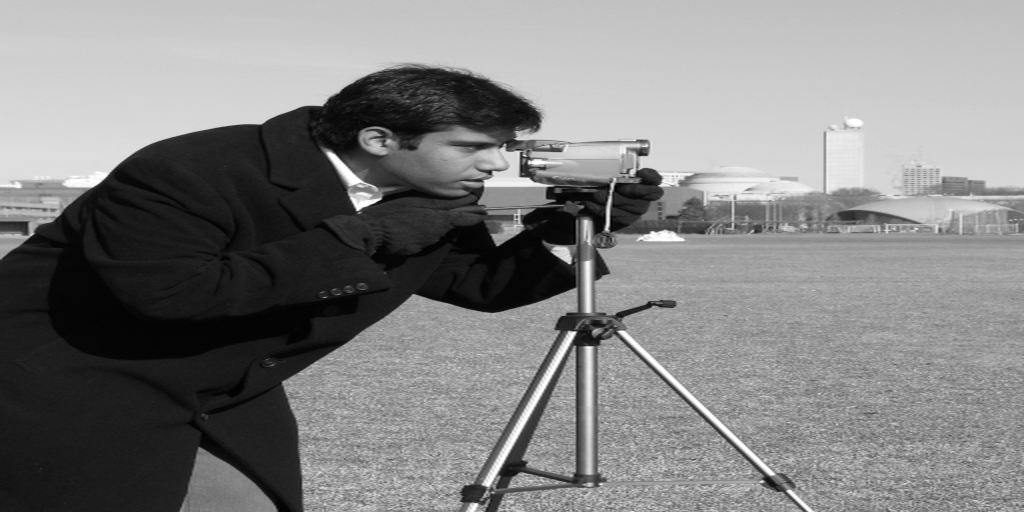

In [7]:
nonuniform_img = img.resize(new_size_nu, resample=Image.LANCZOS)
nonuniform_img

In [8]:
nonuniform_img.save("task1_1b_non_uniform_scaled.jpg")
print(f"Original size:    {img.size}")
print(f"Non-uniform size: {nonuniform_img.size}")

Original size:    (512, 512)
Non-uniform size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size:  (700, 700)


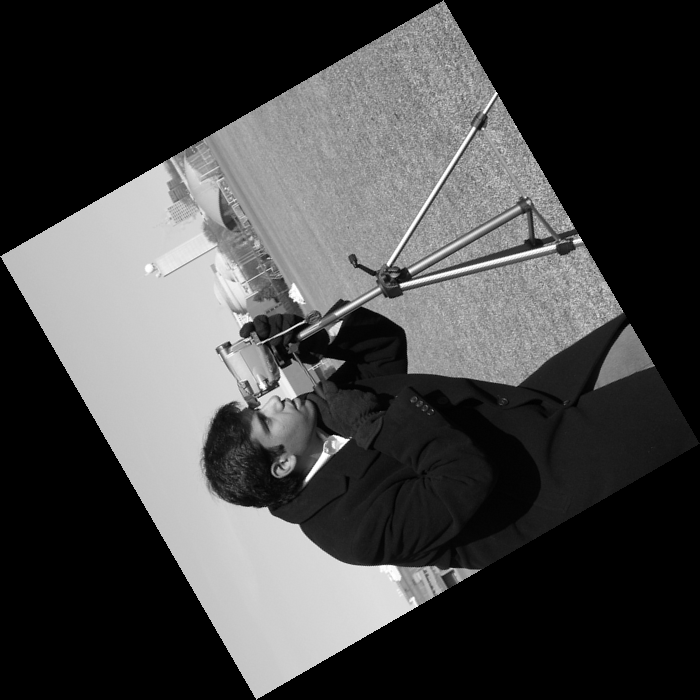

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_img = img.rotate(120, expand=True, resample=Image.BICUBIC)

# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

rotated_img.save("task1_2_rotated.jpg")
print(f"Original size: {img.size}")
print(f"Rotated size:  {rotated_img.size}")
rotated_img

### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
w, h = img.size
print(f"Width: {w}, Height: {h}")

Width: 512, Height: 512


In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5
shx = shear_factor
shy = 0

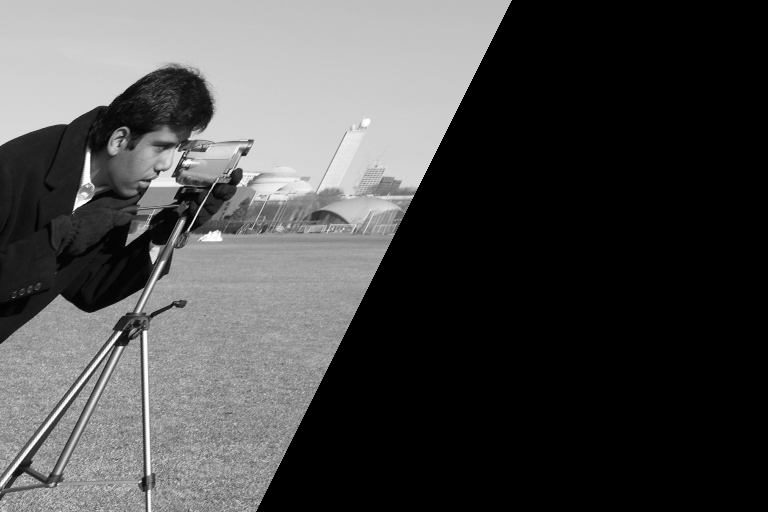

In [14]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
new_width = int(w + abs(shx) * h)
new_height = int(h + abs(shy) * w)

# Shift the image back into view if the shear factor is negative
tx = -abs(shx) * h if shx < 0 else 0
ty = -abs(shy) * w if shy < 0 else 0

sheared_img = img.transform( 
    (new_width, new_height),
     Image.AFFINE 
    ,(1, shx, tx, shy, 1, ty),
    resample=Image.BICUBIC,
       )
sheared_img

In [15]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")
print(f"Original size: {img.size}")
print(f"Sheared size:  {sheared_img.size}")

Original size: (512, 512)
Sheared size:  (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

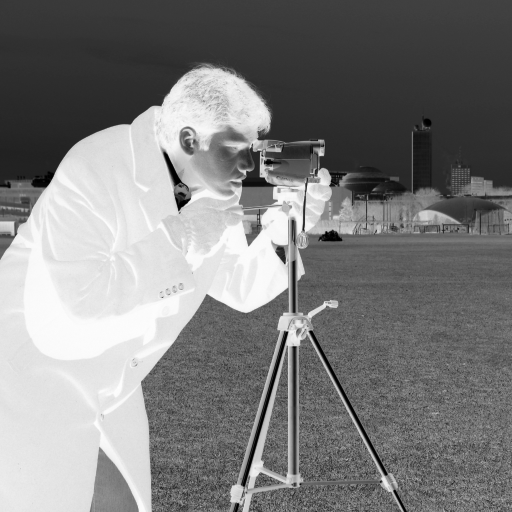

In [16]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
img_array = np.array(img)
negative_array = 255 - img_array
negative_img_np = Image.fromarray(negative_array.astype(np.uint8))
negative_img_np.save("task2_1_negative_numpy.jpg")
negative_img_np



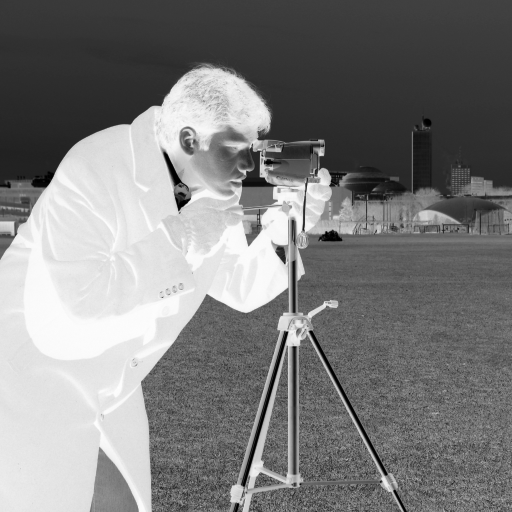

In [17]:
# Method 2: PIL's ImageOps
negative_img_pil = ImageOps.invert(img)
negative_img_pil.save("task2_1_negative_pil.jpg")
negative_img_pil

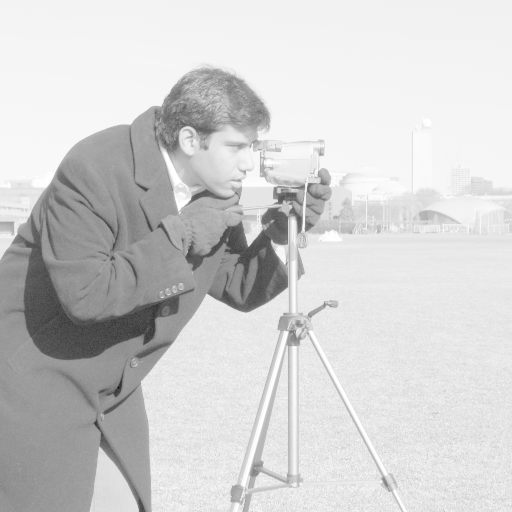

In [18]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
img_array_f = np.array(img, dtype=np.float64)
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_array = c * np.log(1 + img_array_f)
log_img = Image.fromarray(log_array.astype(np.uint8))
log_img.save("task2_2_log.jpg")
log_img



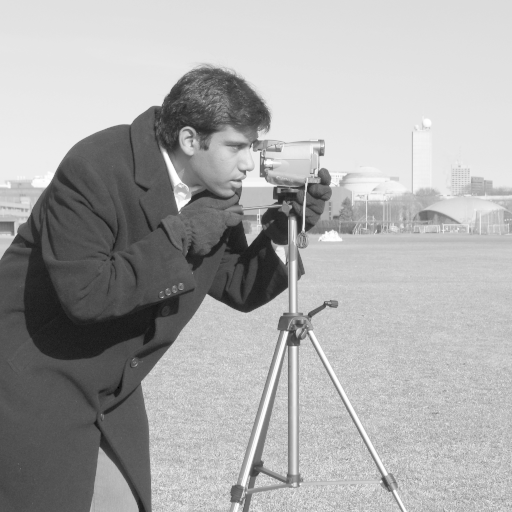

In [19]:

# ── 3. Power-law / Gamma correction ───────────────
img_array_norm = np.array(img, dtype=np.float64) / 255.0
gamma = 0.5 

gamma_array = np.power(img_array_norm, gamma)
gamma_array = (gamma_array * 255).astype(np.uint8)
gamma_img = Image.fromarray(gamma_array)
gamma_img.save("task2_3_gamma.jpg")
gamma_img